In [1]:
import keras
import datetime
import tensorflow                       as tf
from tensorflow.keras.callbacks         import TensorBoard
from tensorflow.keras.layers            import Input,Lambda,UpSampling2D,Conv2D,Dropout,MaxPooling2D,Conv2DTranspose,concatenate,Flatten,BatchNormalization, Activation,ConvLSTM2D,TimeDistributed, GlobalAveragePooling2D, GlobalMaxPooling2D, Add, multiply,Reshape,RepeatVector,LayerNormalization
from tensorflow.keras.models            import Model
from tensorflow.keras.optimizers        import Adam,RMSprop,SGD
from keras.utils                        import plot_model
from tensorflow.keras                   import layers, models
from tensorflow.keras.losses            import mae
from tensorflow.keras.callbacks         import LearningRateScheduler,Callback,CSVLogger

from sklearn.metrics                    import mean_squared_error,r2_score,mean_absolute_error

import sys
import os
import numpy as np
import math
import time
import random, time
from pathlib                        import Path
from PIL                            import Image

import skimage                      as ski
from   skimage.filters              import threshold_otsu
from   skimage                      import io, color
from   skimage.color                import rgb2gray
from   skimage                      import filters
import cv2                          as cv
import matplotlib.pyplot            as plt 
import gc
import glob
from skimage                        import img_as_ubyte
from skimage                        import io
import shutil
import pandas as pd
tf.keras.backend.clear_session()

2025-06-21 08:41:50.378950: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-21 08:41:50.501221: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-21 08:41:50.589937: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-21 08:41:50.606273: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-21 08:41:50.706837: I tensorflow/core/platform/cpu_feature_guar

In [2]:
directory= os.path.abspath("/home/guiomar/Desktop/CODES/predicting-flow-patterns")
sys.path.append(directory)
from NpyDataGenerator import DataGenerator
from tools import *

### 1. Dataset Creation and Loading

In [3]:
directory = '/home/guiomar/Desktop/CODES/predicting-flow-patterns'
#directory = '/home/ppgi/Trabajo/predicting-flow-patterns'

d1=directory+'/G_Masked'
d2=directory+'/P_Masked'
d3=directory+'/V_Masked'
d4=directory+'/Vx_Masked'
d5=directory+'/Vy_Masked'

gtrain= d1+'/train'
gtest=d1+'/test'
gval=d1+'/valid'

ptrain=d2+'/train'
ptest=d2+'/test'
pval=d2+'/valid'

vtrain=d3+'/train'
vtest=d3+'/test'
vval=d3+'/valid'

vxtrain=d4+'/train'
vxtest=d4+'/test'
vxval=d4+'/valid'

vytrain=d5+'/train'
vytest=d5+'/test'
vyval=d5+'/valid'

nbatch = 10

In [4]:
g_train = sorted(glob.glob(os.path.join(gtrain, "*.npy")))
g_test  = sorted(glob.glob(os.path.join(gtest, "*.npy")))
g_val   = sorted(glob.glob(os.path.join(gval, "*.npy")))

p_train = sorted(glob.glob(os.path.join(ptrain, "*.npy")))
p_test  = sorted(glob.glob(os.path.join(ptest, "*.npy")))
p_val   = sorted(glob.glob(os.path.join(pval, "*.npy")))

v_train = sorted(glob.glob(os.path.join(vtrain, "*.npy")))
v_test  = sorted(glob.glob(os.path.join(vtest, "*.npy")))
v_val   = sorted(glob.glob(os.path.join(vval, "*.npy")))

vx_train = sorted(glob.glob(os.path.join(vxtrain, "*.npy")))
vx_test  = sorted(glob.glob(os.path.join(vxtest, "*.npy")))
vx_val   = sorted(glob.glob(os.path.join(vxval, "*.npy")))

vy_train = sorted(glob.glob(os.path.join(vytrain, "*.npy")))
vy_test  = sorted(glob.glob(os.path.join(vytest, "*.npy")))
vy_val   = sorted(glob.glob(os.path.join(vyval, "*.npy")))

train_ds=DataGenerator(g_train,p_train,v_train,vx_train,vy_train)
test_ds=DataGenerator(g_test,p_test,v_test,vx_test,vy_test)
val_ds=DataGenerator(g_val,p_val,v_val,vx_val,vy_val)

### 2. Hyperparameters

In [5]:
num_epochs    =200  #200
patience      =15     # How long to wait after last time validation loss improved #15
LR            =0.001

# Model name
model_names=['Unet_ConvLSTM']
NamesKeras=['Arch_1.keras','Arch_2.keras','Arch_3.keras','Arch_4.keras','Arch_5.keras']
model_name    =model_names[0]
save_in      ='/home/guiomar/Desktop/CODES/predicting-flow-patterns'
#save_in       ='/home/ppgi/Trabajo/predicting-flow-patterns'

# image dimensions
img_width     =  256   # 739   G:737
img_height    =  64   # 185
channel       =  1


number_of_filters = [64,128,256,512]

type_padding = 'same'
f_activation = 'relu'
f_activation_last='relu'
DECAY_RATE=0.04

### 3. Exponential Decay Learning Rate

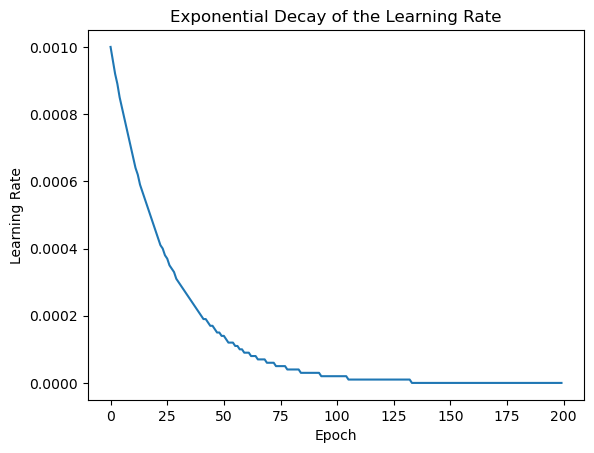

In [6]:
def exponential_decay(epoch,lr_ini=LR,decay_rate=DECAY_RATE,epochs=num_epochs):
    if epoch < epochs*0.001:
        return lr_ini
    else:
        return  lr_ini * np.exp(-decay_rate*epoch)
    
epochs = np.arange(num_epochs)
learning_rates = [round(exponential_decay(epoch),5) for epoch in epochs]


plt.plot(epochs, learning_rates, label="Learning Rate")
plt.title("Exponential Decay of the Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(False)
plt.show()  

### 4. Callbacks

In [7]:
lr_scheduler = LearningRateScheduler(lambda epoch: exponential_decay(epoch), verbose=1)
optimizer = Adam(learning_rate=LR)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',  min_delta=1e-2, patience=patience, restore_best_weights=True,verbose=1)
save = save_in + '/Unet_ConvLSTM_weights/Test3_Best_weights.weights.h5'
checkpoint_weight=tf.keras.callbacks.ModelCheckpoint(save,save_weights_only=True)
checkpoint_keras = tf.keras.callbacks.ModelCheckpoint(NamesKeras[2],save_best_only=True)
csv_logger = CSVLogger('training_log.csv', append=False)


I0000 00:00:1750509714.808570    3919 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-06-21 08:41:55.047905: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [8]:
def conv_block_batchnorm(filters,x):
    conv = Conv2D(filters, (3, 3), padding=type_padding)(x)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    conv = Conv2D(filters, (3, 3), padding=type_padding)(conv)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    return conv
    
def conv2d1(x,filters,number):
	x=Conv2D(filters, (1, 1), activation='relu', padding=type_padding, name=f'K_{number}')(x)
	return x
	    
def conv_block(filters,x):
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(x)
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(conv)
    return conv    
    
def encoder(x,filters,number):
    conv = conv_block_batchnorm(filters,x)
    conv = conv2d1(conv,filters,number)
    downsample = MaxPooling2D((2,2))(conv)
    return conv,downsample

	
def convLSTM_block(filters,x):	
  	x_reshape= Lambda(lambda xx: tf.reshape(xx, (tf.shape(xx)[0],1,tf.shape(xx)[1], tf.shape(xx)[2], tf.shape(xx)[3])))(x)
  	conv_lstm = ConvLSTM2D(filters, (3, 3), padding=type_padding, return_sequences=True)(x_reshape)
  	conv_lstm = ConvLSTM2D(filters, (3, 3), padding=type_padding, return_sequences=True)(conv_lstm)
  	conv_lstm = ConvLSTM2D(filters, (3, 3), padding=type_padding, return_sequences=False)(conv_lstm)
  	return conv_lstm 

def decoder(x1,x2,filters,transpose=None):
    if transpose != None:
        conv_up = Conv2DTranspose(filters,(2,2),strides=(2, 2),padding=type_padding)(x1)
    else:
        conv_up = UpSampling2D((2, 2))(x1)
   
    concat=concatenate([conv_up,x2],axis = 3)
    up = conv_block(filters, concat)
    return up	

In [9]:
def make_model():
    image_input = Input((img_height, img_width, channel)) 
    s1,x1 =   encoder(image_input,number_of_filters[0],1) 
    s2,x2 =   encoder(x1,number_of_filters[1],2) 
    s3,x3 =   encoder(x2,number_of_filters[2],3) 
    s4,x4 =   encoder(x3,number_of_filters[3],4) 
	
    x5 = conv_block(number_of_filters[3],x4)
    x6 = convLSTM_block(number_of_filters[3],x5)
	
    up7=decoder(x5,s4,number_of_filters[3],transpose='yes')
    up8=decoder(up7,s3,number_of_filters[2],transpose='yes')
    up9=decoder(up8,s2,number_of_filters[1],transpose='yes')
    up10=decoder(up9,s1,number_of_filters[0],transpose='yes')
	
    flows_out = Conv2D(4, (1, 1), activation=f_activation_last,name='flows_output',padding="same")(up10)
	
		 # construct model
    model =  keras.Model(inputs=image_input, outputs=[flows_out],name= model_name)
	    
    model.summary()
   
    model.compile(optimizer=optimizer, 
              loss = 'mean_squared_error',
              
              metrics= ['mae', "root_mean_squared_error"] )

    return model  


### 5. Architecture

In [10]:
M=make_model()

Model: "Unet_ConvLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 256,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 256,   │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 256,   │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 256,   │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 256,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ K_1 (Conv2D)        │ (None, 64, 256,   │      4,160 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 128,   │          0 │ K_1[0][0]         │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 128,   │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 128,   │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ K_2 (Conv2D)        │ (None, 32, 128,   │     16,512 │ activation_3[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 64,    │          0 │ K_2[0][0]       

 Total params: 20,900,804 (79.73 MB)

 Trainable params: 20,896,964 (79.72 MB)

 Non-trainable params: 3,840 (15.00 KB)

### 6. Parameters Number

In [11]:
params_simple = M.count_params()
print('Parameters Number: ', params_simple)

Parameters Number:  20900804


### 7. Fitting

In [12]:
print("Starting training")
start_time_for_fit = time.time()
history = M.fit(train_ds,epochs=num_epochs,validation_data = val_ds,
                callbacks=[lr_scheduler,early_stopping,checkpoint_weight,checkpoint_keras,csv_logger])
end_time_for_fit = time.time()
Training_time = end_time_for_fit - start_time_for_fit
print(f"TRAINING TIME IN  {Training_time:.4f} segundos.")
    

Starting training

Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/200


/home/guiomar/micromamba/envs/My_Env/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1400/1400 ━━━━━━━━━━━━━━━━━━━━ 1244s 886ms/step - loss: 0.0081 - mae: 0.0452 - root_mean_squared_error: 0.0817 - val_loss: 4.1944e-04 - val_mae: 0.0150 - val_root_mean_squared_error: 0.0205 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0009607894391523232.
Epoch 2/200
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 1270s 907ms/step - loss: 8.0001e-05 - mae: 0.0057 - root_mean_squared_error: 0.0089 - val_loss: 4.0745e-05 - val_mae: 0.0044 - val_root_mean_squared_error: 0.0064 - learning_rate: 9.6079e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009231163463866358.
Epoch 3/200
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 1261s 901ms/step - loss: 6.0182e-05 - mae: 0.0048 - root_mean_squared_error: 0.0077 - val_loss: 0.0010 - val_mae: 0.0231 - val_root_mean_squared_error: 0.0319 - learning_rate: 9.2312e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0008869204367171575.
Epoch 4/200
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 1259s 899ms/step - loss: 5.7764e-05 - m

### 8. Evaluation

In [13]:
results = M.evaluate(test_ds) 
print("Evaluation results:")
for name, value in zip(M.metrics_names, results):
    print(f"{name}: {value:.4f}")

200/200 ━━━━━━━━━━━━━━━━━━━━ 51s 255ms/step - loss: 4.2538e-04 - mae: 0.0151 - root_mean_squared_error: 0.0206
Evaluation results:
loss: 0.0004
compile_metrics: 0.0151


### 9. Prediction

In [14]:
best_weights=save
M.load_weights(best_weights)

In [15]:
ytrue,ypred=predicting_error(test_ds,M)

*** Starting ***
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━

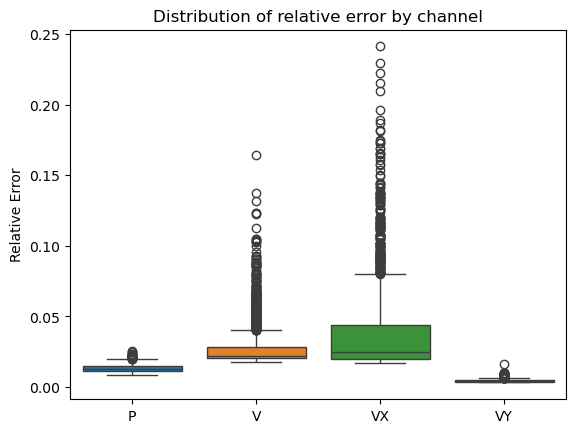

In [16]:
relative_error(ypred,ytrue)

### 10. Figures

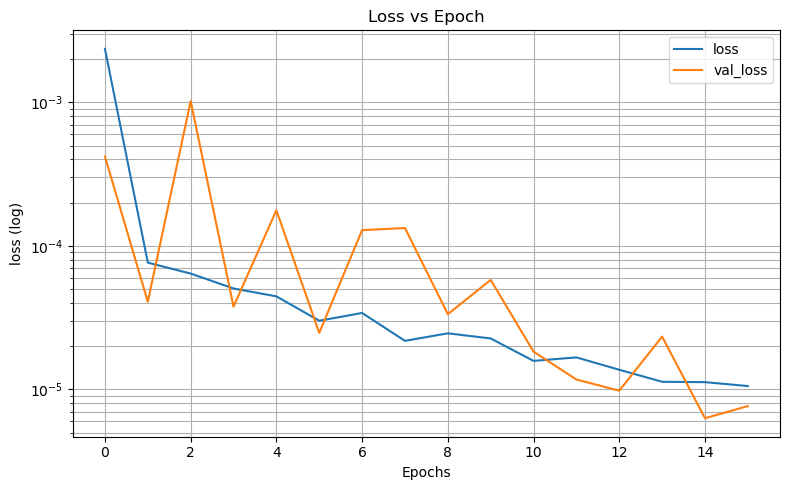

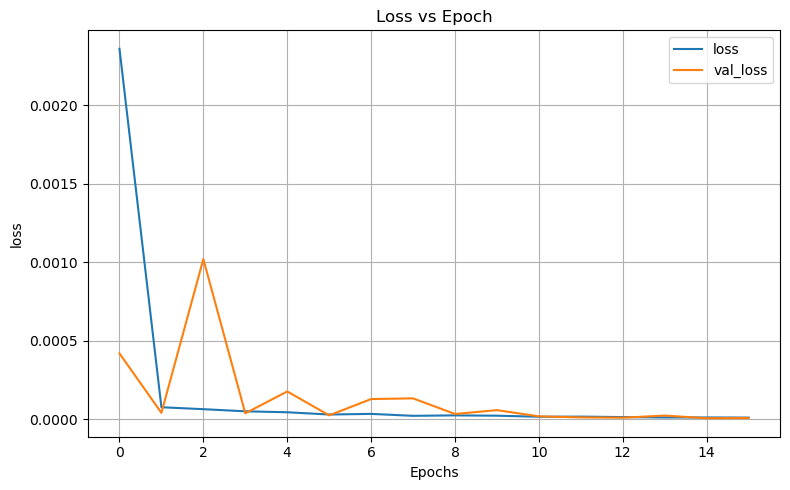

In [17]:
plot_model(history,'loss','val_loss',"Loss vs Epoch",True)

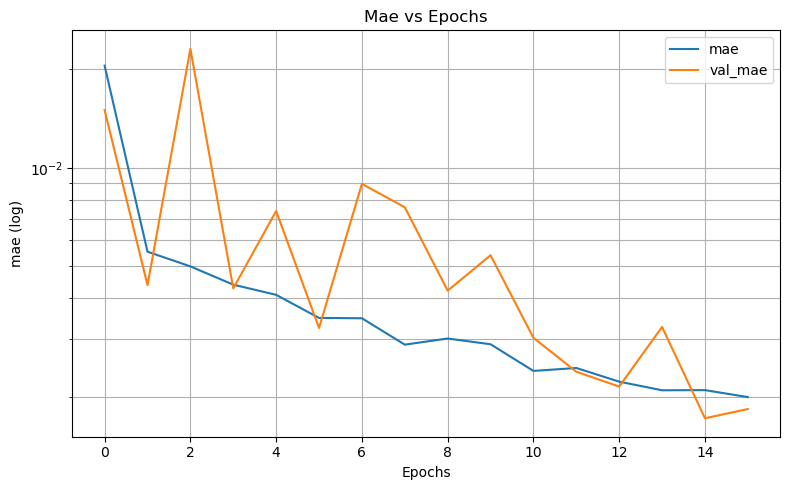

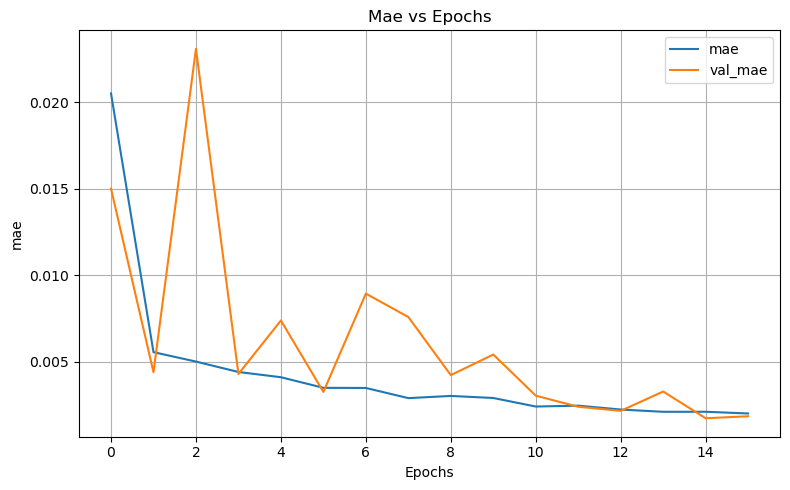

In [18]:
plot_model(history,'mae','val_mae',"Mae vs Epochs",True)

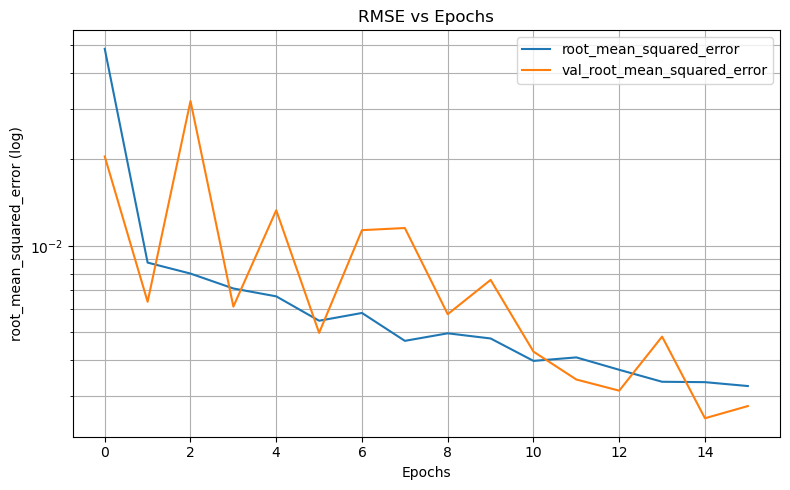

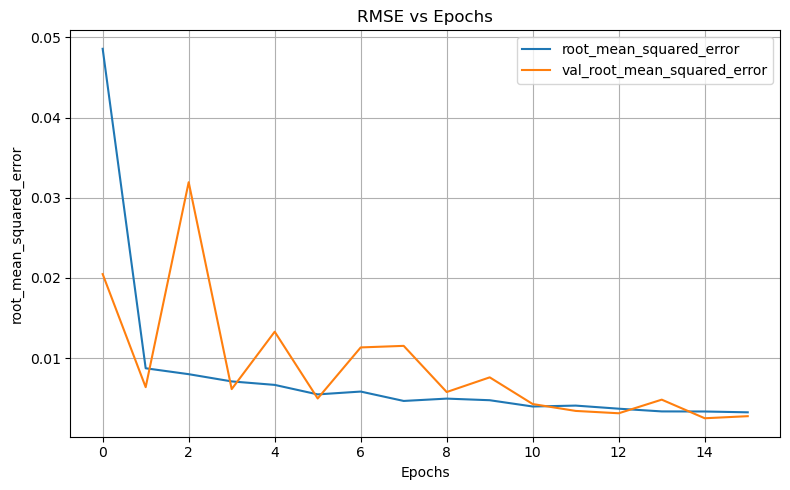

In [19]:
plot_model(history,'root_mean_squared_error','val_root_mean_squared_error',"RMSE vs Epochs",True)

### 11. Qualitative Visualization

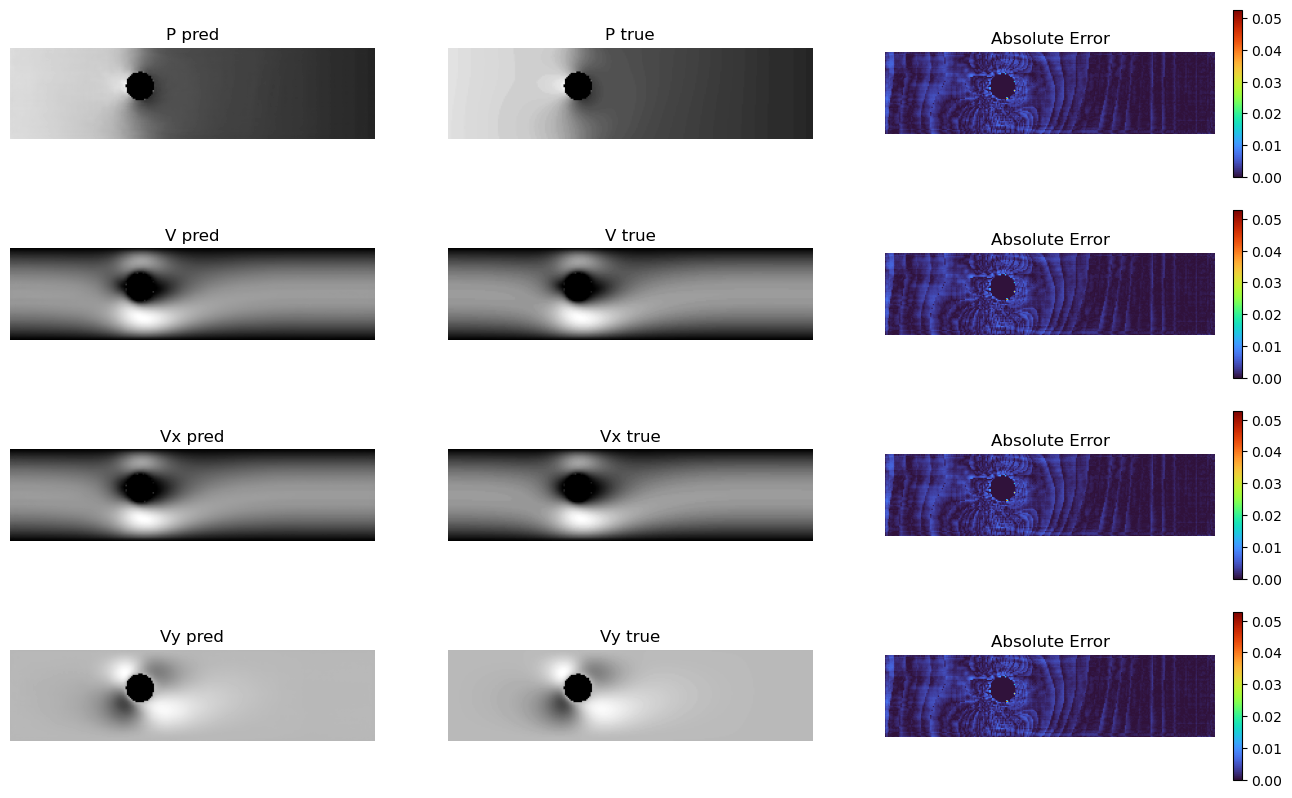

In [20]:
plotting(ytrue,ypred,'visualization_01')

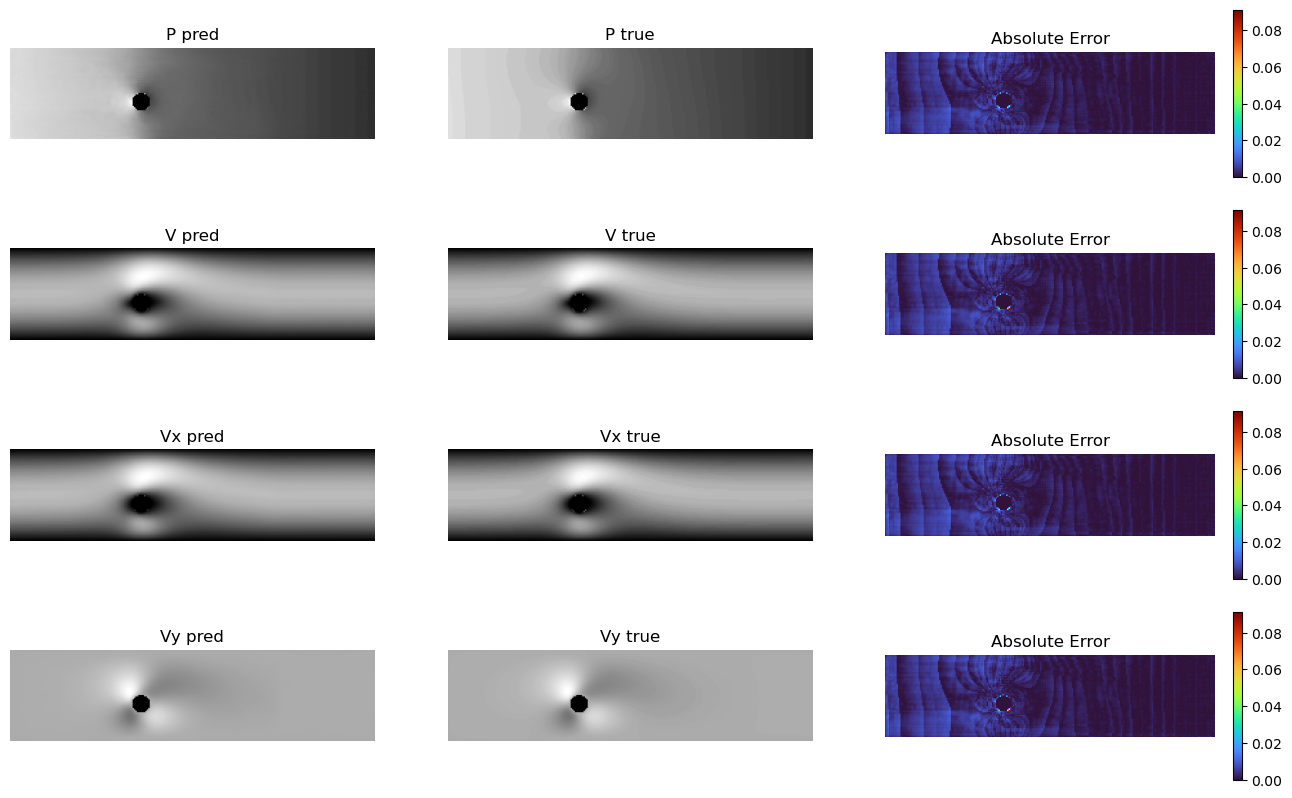

In [21]:
plotting(ytrue,ypred,'visualization_02')

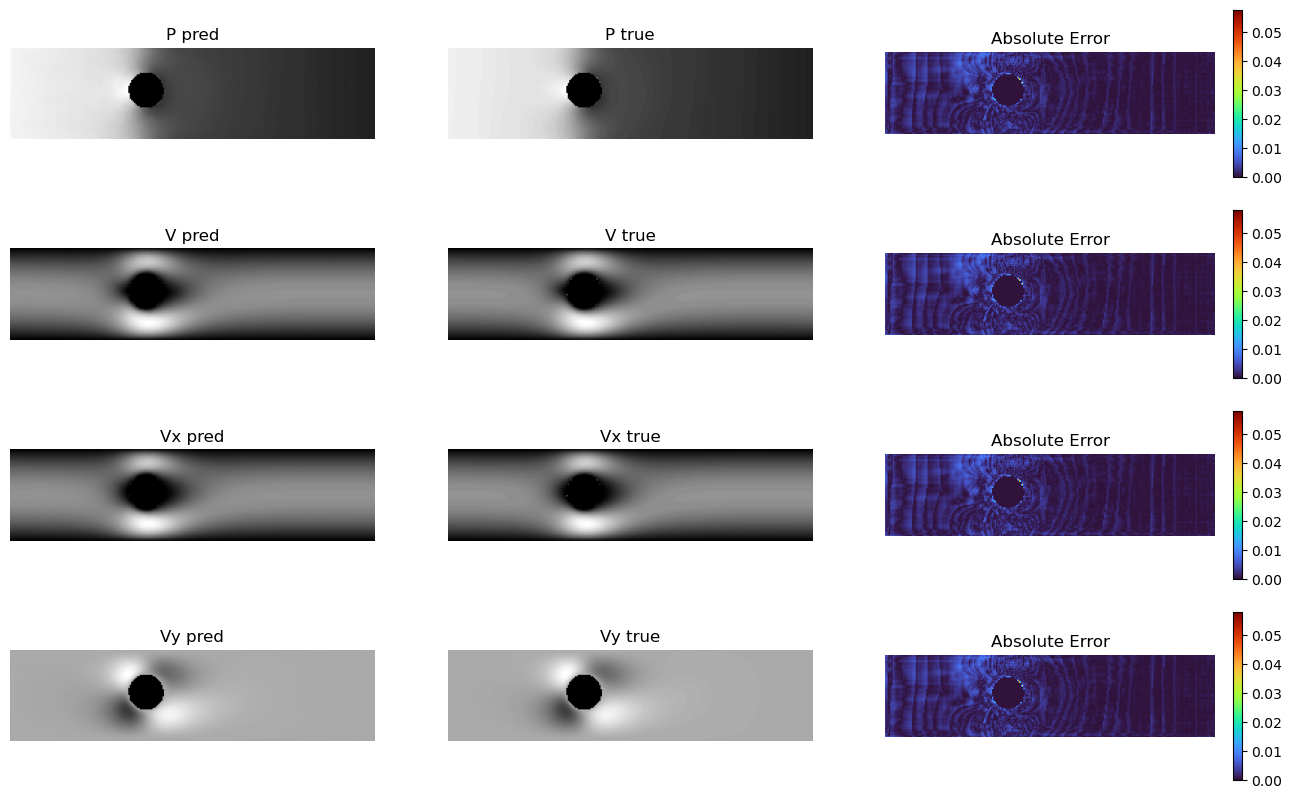

In [22]:
plotting(ytrue,ypred,'visualization_03')

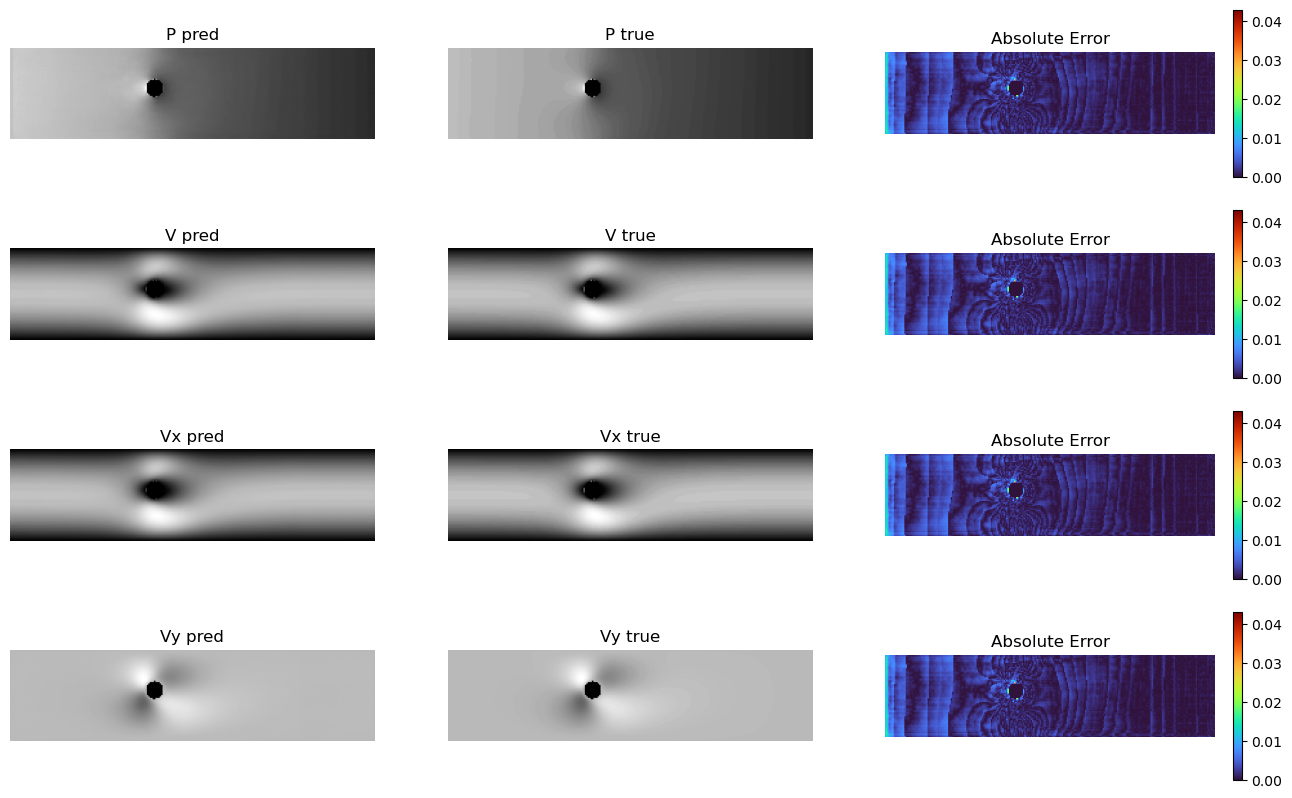

In [23]:
plotting(ytrue,ypred,'visualization_04')

In [24]:
metric_by_channels(ypred,ytrue)

p: MSE = 0.000011, MAE = 0.001911, RMSE =0.003301
v: MSE = 0.000008, MAE = 0.001883, RMSE =0.002750
vx: MSE = 0.000008, MAE = 0.001877, RMSE =0.002741
vy: MSE = 0.000005, MAE = 0.001713, RMSE =0.002325
MSE global: 0.000008
MAE global: 0.001846
MAE % global: 0.184600
RMSE global: 0.002801
